## Imports and Setup

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pywt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from sklearn.model_selection import TimeSeriesSplit # For cross-validation if needed
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # For detail coefficient analysis

## Data Loading and Preparation

In [55]:
# Make sure to upload the 'carbonmonitor-eu_datas_2025-04-04.csv' file to your Colab environment,
# or replace the filename with the correct path to your data file.
data = pd.read_csv('carbonmonitor-eu_datas_2025-04-04.csv')

# Check if 'Unnamed: 4' column exists before dropping
if 'Unnamed: 4' in data.columns:
    data = data.drop(['Unnamed: 4'], axis=1)

data['date'] = pd.to_datetime(data['date'], format='%d/%m/%Y')

# Filter data for Germany
data = data.loc[data['country'] == 'Croatia'].copy()
data.sort_values(by='date', inplace=True)

# Aggregate to monthly data
data['month_year'] = data['date'].dt.to_period('M')
data = data.groupby('month_year')['value'].sum().reset_index()
data['month_year'] = data['month_year'].dt.to_timestamp() # Convert Period to Timestamp for plotting

print(data.head())

  month_year     value
0 2019-01-01  1.737946
1 2019-02-01  1.510222
2 2019-03-01  1.528904
3 2019-04-01  1.426211
4 2019-05-01  1.383128


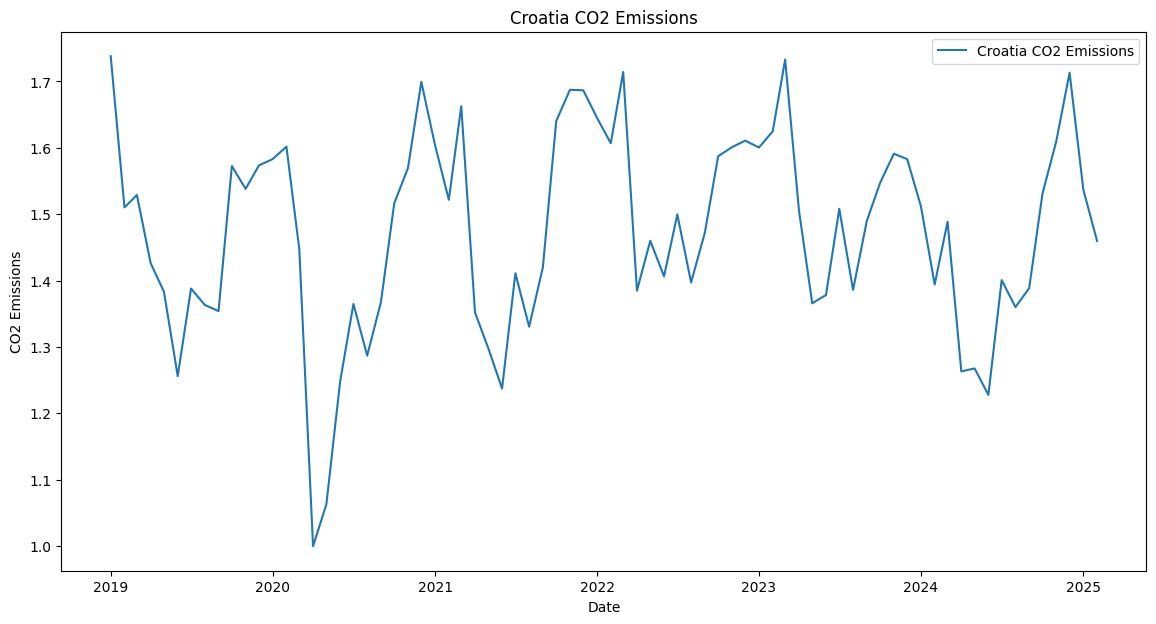

In [76]:
plt.figure(figsize=(14, 7))
plt.plot(data['month_year'], data["value"], label='Croatia CO2 Emissions')
plt.title('Croatia CO2 Emissions')
plt.xlabel('Date')
plt.ylabel('CO2 Emissions')
plt.legend()
plt.show()

## Tests

In [57]:
import numpy as np
from scipy.stats import kruskal

# Group data by year_month_dt and extract the 'value' column for each group
groups = [group['value'].values for name, group in data.groupby('month_year')]

# Perform the Kruskal-Wallis test
stat, p = kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {stat}")
print(f"P-value: {p}")

Kruskal-Wallis H-statistic: 73.0
P-value: 0.4779857234526861


In [58]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-Fuller test on the original series
original_result = adfuller(data["value"])

print(f"ADF Statistic (Original): {original_result[0]:.4f}")
print(f"p-value (Original): {original_result[1]:.4f}")

if original_result[1] < 0.05:
  print("Interpretation: The original series is Stationary.\n")
else:
  print("Interpretation: The original series is Non-Stationary.\n")

# Apply first-order differencing
data['Value_Diff'] = data['value'].diff()

# Perform the Augmented Dickey-Fuller test on the differenced series
result_diff = adfuller(data["Value_Diff"].dropna())
print(f"ADF Statistic (Differenced): {result_diff[0]:.4f}")
print(f"p-value (Differenced): {result_diff[1]:.4f}")

if result_diff[1] < 0.05:
  print("Interpretation: The differenced series is Stationary.")
else:
  print("Interpretation: The differenced series is Non-Stationary.")

ADF Statistic (Original): -1.4181
p-value (Original): 0.5736
Interpretation: The original series is Non-Stationary.

ADF Statistic (Differenced): -3.2582
p-value (Differenced): 0.0169
Interpretation: The differenced series is Stationary.


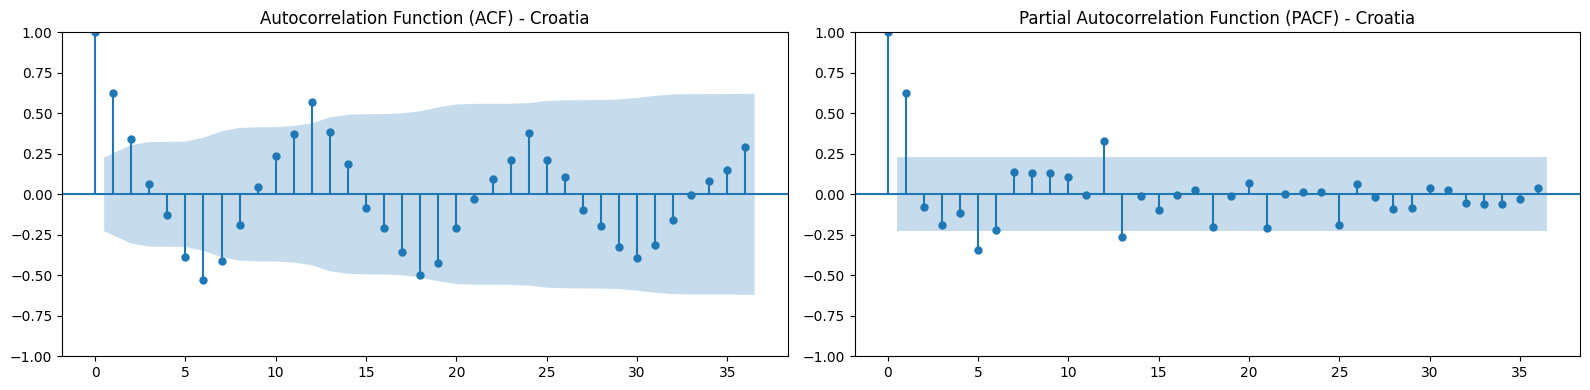

In [59]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the differenced series
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# ACF plot
plot_acf(data['value'].dropna(), lags=36, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) - Croatia')

# PACF plot
plot_pacf(data['value'].dropna(), lags=36, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF) - Croatia')

plt.tight_layout()
plt.show()

In [70]:
# Split data - keep the original split for evaluation purposes later
covid_end = '2023-05-01'
train= data[data['month_year'] < covid_end].copy()
test = data[data['month_year'] >= covid_end].copy()

print(f"Train set size: {len(train)}")
print(f"Test set size: {len(test)}")

# Model fitting and forecasting code will be re-added after verifying data split
# Fit ARIMA model
model_fit = SARIMAX(train["value"], order=(0, 1, 2), seasonal_order=((0, 1, 1, 12))).fit()

# Generate ARIMA forecast for the test period
forecast_steps = len(test)
forecast = model_fit.forecast(steps=forecast_steps)
arima_forecast = forecast # Assigning to arima_forecast for consistency with later code

Train set size: 52
Test set size: 22


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


## Wavelet-ARIMA Model (Example: Level 4, db8)

In [71]:
# Wavelet parameters that performed best on the single test set
wavelet_type = 'db8'
decomposition_level = 4

# Decompose the FULL series (for consistent coefficient lengths)
full_series = data['value'].values
coeffs_full = pywt.wavedec(full_series, wavelet_type, level=decomposition_level)
# The number of coefficients depends on the level and wavelet type
# For level 4, db8: cA4, cD4, cD3, cD2, cD1
cA_full = coeffs_full[0]
detail_coeffs_full = coeffs_full[1:] # cD4, cD3, cD2, cD1

# Train SARIMA on the approximation of the FULL series
# Using the same example SARIMA parameters for cA
sarima_order_cA = (0, 1, 2)
seasonal_order_cA = (0, 1, 1, 12)

model_full_cA = SARIMAX(cA_full, order=sarima_order_cA, seasonal_order=seasonal_order_cA)
fit_full_cA = model_full_cA.fit()

# Predict the approximation for the entire length of the approximation coefficients
predicted_cA_full = fit_full_cA.predict(start=0, end=len(cA_full) - 1)

# Reconstruct the full series using the predicted approximation and original detail coefficients.
# Use the original detail coefficients from the full series decomposition for reconstruction
reconstructed_coeffs_full = [predicted_cA_full] + list(detail_coeffs_full)
predicted_signal_full = pywt.waverec(reconstructed_coeffs_full, wavelet_type)

# The forecasted values for the test period are the last len(test) points
# from this reconstructed full signal.
forecasted_signal_test_wavelet_arima = predicted_signal_full[-len(test['value']):]

# Scale the Wavelet-ARIMA forecast to the range of the actual test data
actual_test_values = test['value'].values
min_actual = np.min(actual_test_values)
max_actual = np.max(actual_test_values)
min_wavelet = np.min(forecasted_signal_test_wavelet_arima)
max_wavelet = np.max(forecasted_signal_test_wavelet_arima)

# Avoid division by zero if the wavelet forecast is constant or has zero range
if (max_wavelet - min_wavelet) > 1e-6:
    scaled_wavelet_arima_forecast = min_actual + (forecasted_signal_test_wavelet_arima - min_wavelet) * (max_actual - min_actual) / (max_wavelet - min_wavelet)
else:
    scaled_wavelet_arima_forecast = forecasted_signal_test_wavelet_arima + (np.mean(actual_test_values) - np.mean(forecasted_signal_test_wavelet_arima))

/usr/local/lib/python3.11/dist-packages/pywt/_multilevel.py:43: UserWarning: Level value of 4 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


## Exponential Smoothing (ETS) Model

In [72]:
# Instantiate and Fit Exponential Smoothing Model
# Using seasonal='add' and seasonal_periods=12 based on potential monthly seasonality
ets_model = ExponentialSmoothing(train["value"], seasonal='add', seasonal_periods=12)
ets_fit = ets_model.fit()

# Generate forecasts for the test period using ETS
ets_forecast = ets_fit.forecast(steps=len(test))

## Prophet Model

In [73]:
# Prepare data for Prophet
prophet_data = train[['month_year', 'value']].rename(columns={'month_year': 'ds', 'value': 'y'})

# Instantiate and Fit Prophet Model
prophet_model = Prophet()
prophet_model.fit(prophet_data)

# Create future dataframe for forecasting
future = prophet_model.make_future_dataframe(periods=len(test), freq='MS')

# Generate Prophet forecast
prophet_forecast_df = prophet_model.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp_962d3dm/99u8pjgc.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp_962d3dm/uo_ftuj1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=17954', 'data', 'file=/tmp/tmp_962d3dm/99u8pjgc.json', 'init=/tmp/tmp_962d3dm/uo_ftuj1.json', 'output', 'file=/tmp/tmp_962d3dm/prophet_modela_xs30qg/prophet_model-20250720181905.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
18:19:05 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:19:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


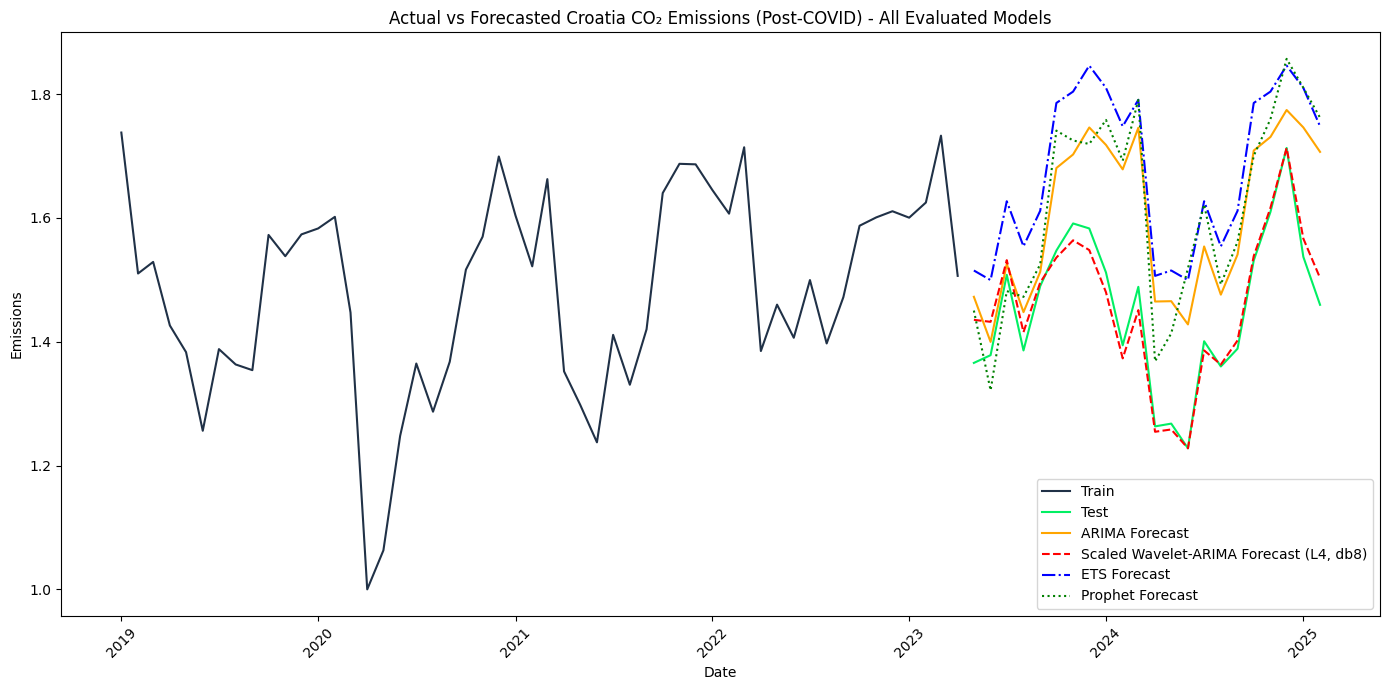

In [77]:
import matplotlib.pyplot as plt

# Plot original data
plt.figure(figsize=(14, 7))
plt.plot(train['month_year'], train["value"], label='Train', color='#203147')
plt.plot(test['month_year'], test["value"], label='Test', color='#01ef63')

# ARIMA-only forecast (assuming 'arima_forecast' variable is still available)
plt.plot(test['month_year'], arima_forecast, label='ARIMA Forecast', color='orange')

# Wavelet-ARIMA forecast (Level 3, db8 with modeled details)
# Assuming scaled_wavelet_arima_forecast holds the forecast
plt.plot(
    test['month_year'],
    scaled_wavelet_arima_forecast,
    label='Scaled Wavelet-ARIMA Forecast (L4, db8)',
    color='red',
    linestyle='--'
)

# ETS Forecast
# Assuming ets_forecast is still available
plt.plot(test['month_year'], ets_forecast, label='ETS Forecast', color='blue', linestyle='-.')

# Prophet Forecast
# Assuming prophet_forecast_df is still available and aligned
prophet_forecast_test_period = prophet_forecast_df[prophet_forecast_df['ds'].isin(test['month_year'])]
plt.plot(prophet_forecast_test_period['ds'], prophet_forecast_test_period['yhat'], label='Prophet Forecast', color='green', linestyle=':')


plt.title('Actual vs Forecasted Croatia CO₂ Emissions (Post-COVID) - All Evaluated Models')
plt.xlabel('Date')
plt.ylabel('Emissions')
plt.legend()
plt.xticks(rotation=45)  # Rotate date labels for readability
plt.tight_layout()
plt.show()

In [78]:
# Function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    epsilon = np.finfo(np.float64).eps
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

# Function to calculate R-squared for time series
def time_series_r_squared(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    variance_actual = np.var(y_true)
    mse_model = mean_squared_error(y_true, y_pred)
    # Handle cases where variance_actual might be zero or very close to zero
    r_squared = 1 - (mse_model / variance_actual) if variance_actual > 1e-9 else np.nan
    return r_squared

# Calculate metrics for SARIMAX
rmse_arima = np.sqrt(mean_squared_error(test['value'], arima_forecast))
mae_arima = mean_absolute_error(test['value'], arima_forecast)
mape_arima = mean_absolute_percentage_error(test['value'], arima_forecast)
r_squared_arima = time_series_r_squared(test['value'], arima_forecast)
# AIC and BIC for the ARIMA model (assuming it's the one fitted in Avw7Rei6--85)
aic_arima = model_fit.aic
bic_arima = model_fit.bic


# Calculate metrics for Scaled Wavelet-ARIMA (Level 4, db8)
rmse_wavelet_arima_l4_db8 = np.sqrt(mean_squared_error(test['value'], scaled_wavelet_arima_forecast))
mae_wavelet_arima_l4_db8 = mean_absolute_error(test['value'], scaled_wavelet_arima_forecast)
mape_wavelet_arima_l4_db8 = mean_absolute_percentage_error(test['value'], scaled_wavelet_arima_forecast)
r_squared_wavelet_arima = time_series_r_squared(test['value'], scaled_wavelet_arima_forecast)
# AIC and BIC for Wavelet-ARIMA: This is tricky as it's a hybrid model.
# We can only provide AIC/BIC for the SARIMA model fitted to the approximation coefficient.
# We will use the AIC/BIC from the SARIMA model fitted to the cA_full in cell BugViIaJA6Ee
aic_wavelet_arima = fit_full_cA.aic
bic_wavelet_arima = fit_full_cA.bic


# Calculate metrics for ETS
rmse_ets = np.sqrt(mean_squared_error(test['value'], ets_forecast))
mae_ets = mean_absolute_error(test['value'], ets_forecast)
mape_ets = mean_absolute_percentage_error(test['value'], ets_forecast)
r_squared_ets = time_series_r_squared(test['value'], ets_forecast)
# AIC and BIC for ETS
aic_ets = ets_fit.aic
bic_ets = ets_fit.bic

# Calculate metrics for Prophet
rmse_prophet = np.sqrt(mean_squared_error(test['value'], prophet_forecast_test_period['yhat']))
mae_prophet = mean_absolute_error(test['value'], prophet_forecast_test_period['yhat'])
mape_prophet = mean_absolute_percentage_error(test['value'], prophet_forecast_test_period['yhat'])
r_squared_prophet = time_series_r_squared(test['value'], prophet_forecast_test_period['yhat'])
# AIC and BIC for Prophet: Prophet does not provide AIC/BIC directly.
# We will use None for these values.
aic_prophet = None
bic_prophet = None


print("Evaluation Metrics (Single Test Set) - Croatia:")
print("-" * 120)
print(f"{'Metric':<10} | {'SARIMAX':<10} | {'Wavelet-ARIMA (L4, db8)':<25} | {'ETS':<10} | {'Prophet':<10}")
print("-" * 120)
print(f"{'RMSE':<10} | {rmse_arima:<10.4f} | {rmse_wavelet_arima_l4_db8:<25.4f} | {rmse_ets:<10.4f} | {rmse_prophet if rmse_prophet is not None else 'N/A':<10}")
print(f"{'MAE':<10} | {mae_arima:<10.4f} | {mae_wavelet_arima_l4_db8:<25.4f} | {mae_ets:<10.4f} | {mae_prophet if mae_prophet is not None else 'N/A':<10}")
print(f"{'MAPE':<10} | {mape_arima:<10.4f} | {mape_wavelet_arima_l4_db8:<25.4f} | {mape_ets:<10.4f} | {mape_prophet if mape_prophet is not None else 'N/A':<10}")
print(f"{'R-squared':<10} | {r_squared_arima:<10.4f} | {r_squared_wavelet_arima:<25.4f} | {r_squared_ets:<10.4f} | {r_squared_prophet if r_squared_prophet is not None else 'N/A':<10}")
print(f"{'AIC':<10} | {aic_arima:<10.4f} | {aic_wavelet_arima:<25.4f} | {aic_ets:<10.4f} | {'N/A':<10}")
print(f"{'BIC':<10} | {bic_arima:<10.4f} | {bic_wavelet_arima:<25.4f} | {bic_ets:<10.4f} | {'N/A':<10}")
print("-" * 120)

Evaluation Metrics (Single Test Set) - Croatia:
------------------------------------------------------------------------------------------------------------------------
Metric     | SARIMAX    | Wavelet-ARIMA (L4, db8)   | ETS        | Prophet   
------------------------------------------------------------------------------------------------------------------------
RMSE       | 0.1648     | 0.0283                    | 0.2318     | 0.1889980163277018
MAE        | 0.1465     | 0.0219                    | 0.2226     | 0.16850303185947266
MAPE       | 10.2411    | 1.5153                    | 15.4579    | 11.679269135241746
R-squared  | -0.8841    | 0.9445                    | -2.7265    | -1.4781393602418702
AIC        | -65.7169   | 8.1309                    | -243.9311  | N/A       
BIC        | -59.0626   | 6.5686                    | -216.6137  | N/A       
------------------------------------------------------------------------------------------------------------------------


Hyperparameter Tuning

In [66]:
# Define the range of parameters to explore
p = range(0, 3)  # Non-seasonal AR order
d = 1            # Non-seasonal differencing order (from ADF test)
q = range(0, 3)  # Non-seasonal MA order
P = range(0, 2)  # Seasonal AR order
D = 1            # Seasonal differencing order (from ACF/PACF and monthly data)
Q = range(0, 2)  # Seasonal MA order
m = 12           # Seasonal period (monthly data)

print(f"p range: {list(p)}")
print(f"d: {d}")
print(f"q range: {list(q)}")
print(f"P range: {list(P)}")
print(f"D: {D}")
print(f"Q range: {list(Q)}")
print(f"m: {m}")

p range: [0, 1, 2]
d: 1
q range: [0, 1, 2]
P range: [0, 1]
D: 1
Q range: [0, 1]
m: 12


In [67]:
import warnings

# Suppress convergence warnings for cleaner output during grid search
warnings.filterwarnings("ignore", category=UserWarning)

# Store results
sarimax_results = {}

# Loop through all possible combinations of p, q, P, and Q
for p_val in p:
    for q_val in q:
        for P_val in P:
            for Q_val in Q:
                order = (p_val, d, q_val)
                seasonal_order = (P_val, D, Q_val, m)
                print(f"Testing SARIMAX with order={order}, seasonal_order={seasonal_order}")

                try:
                    # Fit SARIMAX model
                    model = SARIMAX(train["value"], order=order, seasonal_order=seasonal_order)
                    model_fit = model.fit(disp=False) # disp=False suppresses convergence output

                    # Store the fitted model
                    sarimax_results[(order, seasonal_order)] = model_fit
                    print(f"Successfully fitted SARIMAX with order={order}, seasonal_order={seasonal_order}")

                except Exception as e:
                    print(f"Failed to fit SARIMAX with order={order}, seasonal_order={seasonal_order}: {e}")
                    # Optionally store the error or skip this combination
                    sarimax_results[(order, seasonal_order)] = f"Error: {e}"

# Re-enable warnings
warnings.filterwarnings("default")

print("\nSARIMAX model fitting complete.")
print(f"Number of tested combinations: {len(sarimax_results)}")

Testing SARIMAX with order=(0, 1, 0), seasonal_order=(0, 1, 0, 12)
Successfully fitted SARIMAX with order=(0, 1, 0), seasonal_order=(0, 1, 0, 12)
Testing SARIMAX with order=(0, 1, 0), seasonal_order=(0, 1, 1, 12)
Successfully fitted SARIMAX with order=(0, 1, 0), seasonal_order=(0, 1, 1, 12)
Testing SARIMAX with order=(0, 1, 0), seasonal_order=(1, 1, 0, 12)
Successfully fitted SARIMAX with order=(0, 1, 0), seasonal_order=(1, 1, 0, 12)
Testing SARIMAX with order=(0, 1, 0), seasonal_order=(1, 1, 1, 12)
Successfully fitted SARIMAX with order=(0, 1, 0), seasonal_order=(1, 1, 1, 12)
Testing SARIMAX with order=(0, 1, 1), seasonal_order=(0, 1, 0, 12)
Successfully fitted SARIMAX with order=(0, 1, 1), seasonal_order=(0, 1, 0, 12)
Testing SARIMAX with order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)
Successfully fitted SARIMAX with order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)
Testing SARIMAX with order=(0, 1, 1), seasonal_order=(1, 1, 0, 12)
Successfully fitted SARIMAX with order=(0, 1, 1), seasona

In [68]:
# Initialize dictionary to store metrics
model_metrics = {}

# Iterate through fitted models
for (order, seasonal_order), model_fit in sarimax_results.items():
    # Check if the value is a fitted model object
    if not isinstance(model_fit, str): # Assuming error messages are stored as strings
        try:
            # Calculate AIC and BIC
            aic = model_fit.aic
            bic = model_fit.bic

            # Generate forecasts
            forecast_steps = len(test)
            forecast = model_fit.forecast(steps=forecast_steps)

            # Calculate evaluation metrics
            rmse = np.sqrt(mean_squared_error(test['value'], forecast))
            mae = mean_absolute_error(test['value'], forecast)
            mape = mean_absolute_percentage_error(test['value'], forecast)

            # Calculate R-squared
            variance_actual = np.var(test['value'])
            mse_model = mean_squared_error(test['value'], forecast)
            # Handle cases where variance_actual might be zero or very close to zero
            r_squared = 1 - (mse_model / variance_actual) if variance_actual > 1e-9 else np.nan

            # Store metrics
            model_metrics[(order, seasonal_order)] = {
                'AIC': aic,
                'BIC': bic,
                'RMSE': rmse,
                'MAE': mae,
                'MAPE': mape,
                'R-squared': r_squared
            }

        except Exception as e:
            print(f"Failed to calculate metrics for order={order}, seasonal_order={seasonal_order}: {e}")
            # Store error message or skip
            model_metrics[(order, seasonal_order)] = f"Metric Calculation Error: {e}"

# Print the calculated metrics
print("\nEvaluation Metrics for SARIMAX Models (Single Test Set):")
print("-" * 120)
print(f"{'Order':<15} | {'Seasonal Order':<20} | {'AIC':<10} | {'BIC':<10} | {'RMSE':<10} | {'MAE':<10} | {'MAPE':<10} | {'R-squared':<10}")
print("-" * 120)

for (order, seasonal_order), metrics in model_metrics.items():
    if isinstance(metrics, dict):
        print(f"{str(order):<15} | {str(seasonal_order):<20} | {metrics['AIC']:<10.4f} | {metrics['BIC']:<10.4f} | {metrics['RMSE']:<10.4f} | {metrics['MAE']:<10.4f} | {metrics['MAPE']:<10.4f} | {metrics['R-squared']:<10.4f}")
    else:
        print(f"{str(order):<15} | {str(seasonal_order):<20} | {metrics}")

print("-" * 120)


Evaluation Metrics for SARIMAX Models (Single Test Set):
------------------------------------------------------------------------------------------------------------------------
Order           | Seasonal Order       | AIC        | BIC        | RMSE       | MAE        | MAPE       | R-squared 
------------------------------------------------------------------------------------------------------------------------
(0, 1, 0)       | (0, 1, 0, 12)        | -47.9193   | -46.2557   | 0.2782     | 0.2564     | 18.1184    | -4.3700   
(0, 1, 0)       | (0, 1, 1, 12)        | -60.7559   | -57.4288   | 0.2493     | 0.2396     | 16.6301    | -3.3116   
(0, 1, 0)       | (1, 1, 0, 12)        | -60.9683   | -57.6412   | 0.2481     | 0.2287     | 16.0148    | -3.2690   
(0, 1, 0)       | (1, 1, 1, 12)        | -60.5957   | -55.6050   | 0.2870     | 0.2732     | 18.9833    | -4.7162   
(0, 1, 1)       | (0, 1, 0, 12)        | -48.9730   | -45.6459   | 0.3693     | 0.3467     | 24.3822    | -8.4610  

In [69]:
# Initialize dictionaries to store ranks for each metric
aic_ranks = {}
bic_ranks = {}
rmse_ranks = {}
mae_ranks = {}
mape_ranks = {}
r_squared_ranks = {}

# Filter out models that failed to fit or calculate metrics
valid_models = {params: metrics for params, metrics in model_metrics.items() if isinstance(metrics, dict)}

if not valid_models:
    print("No valid models were fitted or evaluated.")
else:
    # Extract metrics into lists for ranking
    params_list = list(valid_models.keys())
    aic_list = [metrics['AIC'] for metrics in valid_models.values()]
    bic_list = [metrics['BIC'] for metrics in valid_models.values()]
    rmse_list = [metrics['RMSE'] for metrics in valid_models.values()]
    mae_list = [metrics['MAE'] for metrics in valid_models.values()]
    mape_list = [metrics['MAPE'] for metrics in valid_models.values()]
    r_squared_list = [metrics['R-squared'] for metrics in valid_models.values()]

    # Rank models based on each metric (lower rank is better for AIC, BIC, RMSE, MAE, MAPE; higher rank is better for R-squared)
    aic_ranks_values = np.argsort(aic_list)
    bic_ranks_values = np.argsort(bic_list)
    rmse_ranks_values = np.argsort(rmse_list)
    mae_ranks_values = np.argsort(mae_list)
    mape_ranks_values = np.argsort(mape_list)
    # For R-squared, we want higher values to have better ranks, so sort in descending order
    r_squared_ranks_values = np.argsort(r_squared_list)[::-1]

    # Store ranks in dictionaries
    for rank, index in enumerate(aic_ranks_values):
        aic_ranks[params_list[index]] = rank + 1
    for rank, index in enumerate(bic_ranks_values):
        bic_ranks[params_list[index]] = rank + 1
    for rank, index in enumerate(rmse_ranks_values):
        rmse_ranks[params_list[index]] = rank + 1
    for rank, index in enumerate(mae_ranks_values):
        mae_ranks[params_list[index]] = rank + 1
    for rank, index in enumerate(mape_ranks_values):
        mape_ranks[params_list[index]] = rank + 1
    for rank, index in enumerate(r_squared_ranks_values):
        r_squared_ranks[params_list[index]] = rank + 1

    # Calculate combined rank for each model
    combined_ranks = {}
    for params in params_list:
        combined_ranks[params] = (
            aic_ranks.get(params, len(params_list)) +
            bic_ranks.get(params, len(params_list)) +
            rmse_ranks.get(params, len(params_list)) +
            mae_ranks.get(params, len(params_list)) +
            mape_ranks.get(params, len(params_list)) +
            r_squared_ranks.get(params, len(params_list)) # Add R-squared rank
        )

    # Find the parameters with the lowest combined rank
    best_params_combined_rank = min(combined_ranks, key=combined_ranks.get)
    best_metrics_combined_rank = valid_models[best_params_combined_rank]

    # Print the best_params based on combined rank and its corresponding metrics
    print("\nBest SARIMAX Model Parameters (based on Combined Rank of AIC, BIC, RMSE, MAE, MAPE, R-squared):")
    print(f"Order: {best_params_combined_rank[0]}")
    print(f"Seasonal Order: {best_params_combined_rank[1]}")
    print(f"Combined Rank: {combined_ranks[best_params_combined_rank]}")
    print("\nCorresponding Metrics:")
    print(f"  AIC: {best_metrics_combined_rank['AIC']:.4f}")
    print(f"  BIC: {best_metrics_combined_rank['BIC']:.4f}")
    print(f"  RMSE: {best_metrics_combined_rank['RMSE']:.4f}")
    print(f"  MAE: {best_metrics_combined_rank['MAE']:.4f}")
    print(f"  MAPE: {best_metrics_combined_rank['MAPE']:.4f}")
    if 'R-squared' in best_metrics_combined_rank:
        print(f"  R-squared: {best_metrics_combined_rank['R-squared']:.4f}")


Best SARIMAX Model Parameters (based on Combined Rank of AIC, BIC, RMSE, MAE, MAPE, R-squared):
Order: (0, 1, 2)
Seasonal Order: (0, 1, 1, 12)
Combined Rank: 19

Corresponding Metrics:
  AIC: -65.7169
  BIC: -59.0626
  RMSE: 0.1648
  MAE: 0.1465
  MAPE: 10.2411
  R-squared: -0.8841
